# Etapa 2 — Reto *3Scenes*: clasificación de escenas con CNN, transferencia y ensamble
**Curso:** Visión por Computador Avanzada (PCJIC, 2026-2) · **Autor:** Milton Alvarado

**Base de clase.** Dataset 3scenes (clases `coast`, `forest`, `highway`; imágenes 256×256).
* `3scenesML.ipynb`: características $[\mu_R,\mu_G,\mu_B,\sigma_R,\sigma_G,\sigma_B]$ + `MLPClassifier`, partición 75/25 con `random_state=20` → **exactitud 81 %** (F1 macro 0.80, F1 ponderado 0.81).
* `3scenesCNN.ipynb`: CNN secuencial Conv(8)-Conv(16)-Conv(32) + Flatten + Dense(3), 256×256, Adam 1e-3, 15 épocas, partición 75/25 con `random_state=40` → **exactitud 88 %** (F1 macro 0.87, F1 ponderado 0.88).

> **Nota metodológica.** En el notebook de la CNN, el conjunto de *prueba* se usa también como `validation_data` durante el entrenamiento; además, las dos líneas base usan particiones distintas.
> Aquí se usa **una sola partición de prueba** (75/25, `random_state=40`, la de la CNN de clase), la validación se separa **del entrenamiento** (15 %) y la prueba solo se toca al final.
> Se reportan exactitud, F1 macro y F1 ponderado para todos los modelos.

**Objetivo (2b):** ≥ 2 resultados nuevos de aprendizaje profundo que superen lo reportado; **(2c):** análisis con fundamentos matemáticos.

**Conexión con la tesis (VI-SLAM):** en la sección 5 se mide un índice de textura por imagen (varianza del Laplaciano y esquinas FAST) y se relaciona con los errores del clasificador:
primera evidencia de que la textura del entorno —un factor del marco DoE— modula el desempeño de un sistema de visión.

## 0. Datos y Drive

In [1]:
!wget -q -nc https://github.com/rubenchov/aprendizajeautomaticovision/releases/download/v2.0.0/3scenes.zip -O /content/3scenes.zip
!unzip -q -n /content/3scenes.zip -d /content/3sc

In [2]:
# Guardar resultados (CSV, figuras) en tu Drive: Ejercicio 2\\resultados\\etapa2
from google.colab import drive
drive.mount('/content/drive')
import os
from pathlib import Path
OUT = Path("/content/drive/MyDrive/PhD/2026_02/Vision_por_computador/Ejercicio 2/resultados/etapa2")
OUT.mkdir(parents=True, exist_ok=True)
os.chdir(OUT)
print("Resultados en:", OUT)

Mounted at /content/drive
Resultados en: /content/drive/MyDrive/PhD/2026_02/Vision_por_computador/Ejercicio 2/resultados/etapa2


Datos en: /content/3sc
(958, 256, 256, 3) {'coast': np.int64(360), 'forest': np.int64(328), 'highway': np.int64(270)}
train/val/test: 610 108 240 | prueba por clase: [85 87 68]


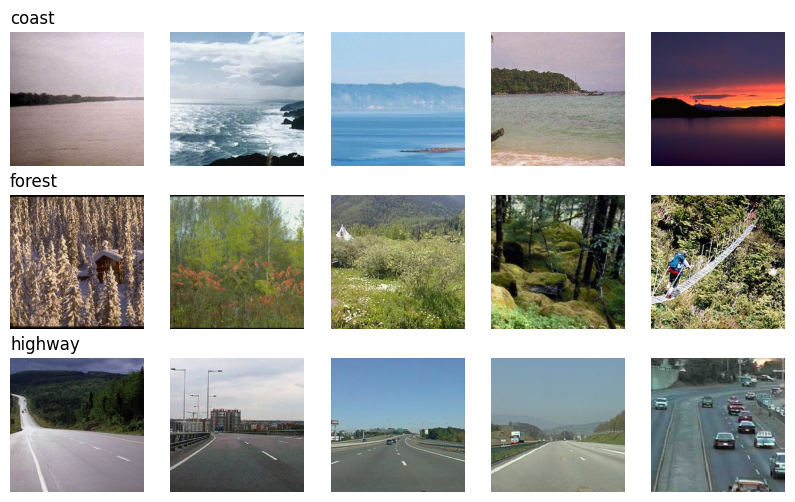

In [3]:
import time, random, warnings, itertools
import numpy as np, pandas as pd, matplotlib.pyplot as plt, cv2
from pathlib import Path
warnings.filterwarnings("ignore")
SEED = 42; random.seed(SEED); np.random.seed(SEED)
SPLIT_SEED = 40                                   # partición de la CNN de clase
classes = ['coast', 'forest', 'highway']; K = len(classes)
IMG = 256                                         # igual que la clase

def find_root(base):
    for p in [base] + sorted(base.rglob("*")):
        if p.is_dir() and set(classes) <= {d.name for d in p.iterdir() if d.is_dir()}: return p
    raise FileNotFoundError("No se encontró una carpeta con coast/ forest/ highway/")
DATA_DIR = find_root(Path("/content/3sc")); print("Datos en:", DATA_DIR)

paths, y = [], []
for ci, c in enumerate(classes):
    for f in sorted(os.listdir(DATA_DIR/c)):           # sorted -> orden reproducible
        if f.lower().endswith('.jpg'): paths.append(str(DATA_DIR/c/f)); y.append(ci)
paths, y = np.array(paths), np.array(y)
X = np.array([cv2.resize(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB), (IMG, IMG), interpolation=cv2.INTER_AREA) for p in paths], np.uint8)
print(X.shape, dict(zip(classes, np.bincount(y))))

from sklearn.model_selection import train_test_split
idx = np.arange(len(y))
i_trfull, i_te = train_test_split(idx, test_size=0.25, random_state=SPLIT_SEED)            # como la clase (no estratificada)
i_tr, i_va = train_test_split(i_trfull, test_size=0.15, stratify=y[i_trfull], random_state=SEED)
Xtr, ytr, Xva, yva, Xte, yte = X[i_tr], y[i_tr], X[i_va], y[i_va], X[i_te], y[i_te]
print("train/val/test:", len(i_tr), len(i_va), len(i_te), "| prueba por clase:", np.bincount(yte))

fig, ax = plt.subplots(K, 5, figsize=(10, 2*K))
for k in range(K):
    for a, i in zip(ax[k], np.random.RandomState(SEED).choice(np.where(ytr==k)[0], 5, replace=False)):
        a.imshow(Xtr[i]); a.axis("off")
    ax[k][0].set_title(classes[k], loc="left")
plt.show()

## 1. Líneas base de ML (replicadas) y mejora clásica
El vector $\phi(x)=[\mu_R,\mu_G,\mu_B,\sigma_R,\sigma_G,\sigma_B]$ (momentos de color de orden 1 y 2) ignora la **estructura espacial**: dos imágenes con los mismos colores en distinto lugar son indistinguibles.
La mejora clásica añade momentos en HSV (tono/saturación separan mejor cielo, mar y vegetación) y un histograma LBP de textura.

In [4]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from skimage.feature import local_binary_pattern

def f_rgb(Xs): return np.hstack([Xs.reshape(len(Xs),-1,3).mean(1), Xs.reshape(len(Xs),-1,3).std(1)])
def f_ext(Xs):
    hsv = np.array([cv2.cvtColor(im, cv2.COLOR_RGB2HSV) for im in Xs]).reshape(len(Xs),-1,3)
    lbp = [np.histogram(local_binary_pattern(cv2.cvtColor(im, cv2.COLOR_RGB2GRAY), 8, 1, "uniform"), bins=10, range=(0,10))[0]/(IMG*IMG) for im in Xs]
    return np.hstack([f_rgb(Xs), hsv.mean(1), hsv.std(1), np.array(lbp)])

results = []; preds = {}
def log(tag, fam, p, extra=None, yt=None):
    yt = yte if yt is None else yt
    r = dict(tag=tag, family=fam, acc=accuracy_score(yt,p), f1_macro=f1_score(yt,p,average="macro"), f1_weighted=f1_score(yt,p,average="weighted"))
    r.update(extra or {}); results.append(r); preds[tag] = p
    print({k:(round(v,3) if isinstance(v,float) else v) for k,v in r.items()})

Ftr_rgb, Fte_rgb = f_rgb(X[i_trfull]), f_rgb(Xte)
# Línea base exacta de clase: MLPClassifier() por defecto sobre momentos RGB, con SU partición (random_state=20)
a_tr, a_te = train_test_split(idx, test_size=0.25, random_state=20)
m = MLPClassifier(random_state=SEED).fit(f_rgb(X[a_tr]), y[a_tr]); log("base_RGB_MLP_split20", "Clase (replicada)", m.predict(f_rgb(X[a_te])), yt=y[a_te]); results[-1]["nota"]="partición rs=20"; preds.pop("base_RGB_MLP_split20")
# Misma línea base sobre la partición común (rs=40) para comparar con todo lo demás
m = MLPClassifier(random_state=SEED).fit(Ftr_rgb, y[i_trfull]); log("base_RGB_MLP", "Clase (replicada)", m.predict(Fte_rgb))
# Mejoras clásicas
Ftr_ext, Fte_ext = f_ext(X[i_trfull]), f_ext(Xte)
m = make_pipeline(StandardScaler(), SVC(C=10, random_state=SEED)).fit(Ftr_ext, y[i_trfull]); log("M1_RGB+HSV+LBP_SVM", "ML clásico", m.predict(Fte_ext))
m = make_pipeline(StandardScaler(), MLPClassifier((64,), max_iter=2000, random_state=SEED)).fit(Ftr_ext, y[i_trfull]); log("M2_RGB+HSV+LBP_MLP", "ML clásico", m.predict(Fte_ext))

{'tag': 'base_RGB_MLP_split20', 'family': 'Clase (replicada)', 'acc': 0.8, 'f1_macro': 0.786, 'f1_weighted': 0.797}
{'tag': 'base_RGB_MLP', 'family': 'Clase (replicada)', 'acc': 0.783, 'f1_macro': 0.767, 'f1_weighted': 0.775}
{'tag': 'M1_RGB+HSV+LBP_SVM', 'family': 'ML clásico', 'acc': 0.908, 'f1_macro': 0.905, 'f1_weighted': 0.908}
{'tag': 'M2_RGB+HSV+LBP_MLP', 'family': 'ML clásico', 'acc': 0.887, 'f1_macro': 0.884, 'f1_weighted': 0.887}


## 2. Aprendizaje profundo
### 2.1 Fundamentos
* **Softmax multiclase** $p_k=e^{z_k}/\sum_j e^{z_j}$ y entropía cruzada $\mathcal L=-\log p_{y}$; gradiente respecto a los logits $=p-y$.
* **Parámetros de la CNN de clase.** Tras 3 *poolings*, el mapa es $32\times32\times32$ y la capa densa tiene $32\,768\cdot3+3=98\,307$ parámetros: el 94 % del modelo está en una sola capa totalmente conectada que memoriza posiciones (se ve en la curva de validación que sube y luego empeora desde la época 8).
  Reemplazar `Flatten` por *Global Average Pooling* reduce esa capa a $C\cdot K+K$ parámetros e impone invariancia a traslación.
* **Campo receptivo.** Con $L$ capas $3\times3$ y *pooling* $2\times2$ el campo receptivo crece ~$2^{L}$: más profundidad capta el *layout* global de la escena (cielo arriba, suelo/mar abajo).
* **BatchNorm y aumento de datos**: estabilizan la escala de activaciones e inyectan invariancias (flip horizontal, rotación y zoom leves, contraste).
* **Transferencia.** $f_\theta=g_{\theta_h}\circ h_{\theta_b}$; se congela $h$ (preentrenada en ImageNet) y se entrena $g$; luego *fine-tuning* con $\eta\sim10^{-5}$.
* **Ensamble por promedio.** $\bar p=\tfrac1M\sum_m p_m$; con errores de varianza $\sigma^2$ y correlación $\rho$: $\mathrm{Var}=\sigma^2\big(\tfrac1M+\tfrac{M-1}{M}\rho\big)$.

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.keras.utils.set_random_seed(SEED); print(tf.__version__, tf.config.list_physical_devices("GPU"))

probs, hist = {}, {}
def fit_eval(tag, model, epochs=40, lr=1e-3, early=True, val=(None, None)):
    model.compile(keras.optimizers.Adam(lr), loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
    cb = [keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True), keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)] if early else []
    vx, vy = (Xva, yva) if val[0] is None else val
    h = model.fit(Xtr if val[0] is None else X[i_trfull], ytr if val[0] is None else y[i_trfull],
                  validation_data=(vx, vy), epochs=epochs, batch_size=32, verbose=0, callbacks=cb)
    pr = model.predict(Xte, verbose=0); probs[tag] = pr; hist[tag] = h.history
    log(tag, "Deep learning", pr.argmax(1), dict(params=model.count_params(), epochs=len(h.history["loss"])))
    return model, h

2.20.0 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
# D0: CNN de clase replicada (misma arquitectura e hiperparámetros; 15 épocas, sin early stopping)
def cnn_clase():
    inp = keras.Input((IMG,IMG,3)); x = layers.Rescaling(1/255.)(inp)
    for f in (8,16,32):
        x = layers.Conv2D(f, 3, padding="same", activation="relu")(x); x = layers.MaxPool2D(2, 2)(x)
    return keras.Model(inp, layers.Dense(K, activation="softmax")(layers.Flatten()(x)))
# (a) como en clase: entrena con train completo y "valida" sobre la prueba
m_d0, h_d0 = fit_eval("D0_CNN_clase", cnn_clase(), epochs=15, early=False, val=(Xte, yte))

{'tag': 'D0_CNN_clase', 'family': 'Deep learning', 'acc': 0.917, 'f1_macro': 0.915, 'f1_weighted': 0.916, 'params': 104339, 'epochs': 15}


In [10]:
# D1: CNN propia -- 4 bloques dobles con BatchNorm, aumento de datos y GAP
aug = keras.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.05), layers.RandomZoom(0.1), layers.RandomContrast(0.1)])
def cnn_bn(depth=4, base=32, drop=0.4):
    inp = keras.Input((IMG,IMG,3)); x = aug(layers.Rescaling(1/255.)(inp))
    for d in range(depth):
        for _ in range(2):
            x = layers.Conv2D(base*2**d, 3, padding="same", use_bias=False)(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
        x = layers.MaxPool2D()(x)
    x = layers.Dropout(drop)(layers.GlobalAveragePooling2D()(x))
    return keras.Model(inp, layers.Dense(K, activation="softmax")(x))
m_cnn, h_cnn = fit_eval("D1_CNN_BN_aug_GAP", cnn_bn(4), epochs=60)

{'tag': 'D1_CNN_BN_aug_GAP', 'family': 'Deep learning', 'acc': 0.296, 'f1_macro': 0.172, 'f1_weighted': 0.151, 'params': 1175907, 'epochs': 9}


In [12]:
# D2: MobileNetV2 congelada (transferencia). Se redimensiona a 224 (resolución de los pesos ImageNet)
TL = 224
base_tl = keras.applications.MobileNetV2((TL,TL,3), include_top=False, weights="imagenet"); base_tl.trainable = False
inp = keras.Input((IMG,IMG,3)); x = aug(inp); x = layers.Resizing(TL, TL)(x); x = keras.applications.mobilenet_v2.preprocess_input(x)
x = layers.Dropout(0.3)(layers.GlobalAveragePooling2D()(base_tl(x, training=False)))
m_tl = keras.Model(inp, layers.Dense(K, activation="softmax")(x))
m_tl, h_tl = fit_eval("D2_MobileNetV2_frozen", m_tl, epochs=25)

{'tag': 'D2_MobileNetV2_frozen', 'family': 'Deep learning', 'acc': 0.983, 'f1_macro': 0.983, 'f1_weighted': 0.983, 'params': 2261827, 'epochs': 25}


In [13]:
# D3: fine-tuning de las últimas ~30 capas con LR pequeño
base_tl.trainable = True
for l in base_tl.layers[:-30]: l.trainable = False
m_tl, h_ft = fit_eval("D3_MobileNetV2_finetune", m_tl, epochs=25, lr=1e-5)

{'tag': 'D3_MobileNetV2_finetune', 'family': 'Deep learning', 'acc': 0.983, 'f1_macro': 0.983, 'f1_weighted': 0.983, 'params': 2261827, 'epochs': 25}


In [14]:
# D4: ensamble por promedio de probabilidades (CNN propia + MobileNetV2 fine-tuned)
pe = (probs["D1_CNN_BN_aug_GAP"] + probs["D3_MobileNetV2_finetune"]) / 2
log("D4_ensemble_D1+D3", "Deep learning", pe.argmax(1))

{'tag': 'D4_ensemble_D1+D3', 'family': 'Deep learning', 'acc': 0.979, 'f1_macro': 0.98, 'f1_weighted': 0.979}


In [20]:
# Re-entrenar D1 con BatchNorm momentum 0.9 y early stopping más paciente; rehacer el ensamble D4
results = [r for r in results if r["tag"] not in ("D1_CNN_BN_aug_GAP", "D4_ensemble_D1+D3")]
def cnn_bn(depth=4, base=32, drop=0.4):
    inp = keras.Input((IMG,IMG,3)); x = aug(layers.Rescaling(1/255.)(inp))
    for d in range(depth):
        for _ in range(2):
            x = layers.Conv2D(base*2**d, 3, padding="same", use_bias=False)(x); x = layers.BatchNormalization(momentum=0.9)(x); x = layers.ReLU()(x)
        x = layers.MaxPool2D()(x)
    x = layers.Dropout(drop)(layers.GlobalAveragePooling2D()(x))
    return keras.Model(inp, layers.Dense(K, activation="softmax")(x))

m = cnn_bn(4)
m.compile(keras.optimizers.Adam(1e-3), loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
h = m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=80, batch_size=32, verbose=0,
          callbacks=[keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=15, start_from_epoch=10, restore_best_weights=True),
                     keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5)])
pr = m.predict(Xte, verbose=0); probs["D1_CNN_BN_aug_GAP"] = pr; hist["D1_CNN_BN_aug_GAP"] = h.history
log("D1_CNN_BN_aug_GAP", "Deep learning", pr.argmax(1), dict(params=m.count_params(), epochs=len(h.history["loss"])))
pe = (probs["D1_CNN_BN_aug_GAP"] + probs["D3_MobileNetV2_finetune"]) / 2
log("D4_ensemble_D1+D3", "Deep learning", pe.argmax(1))

{'tag': 'D1_CNN_BN_aug_GAP', 'family': 'Deep learning', 'acc': 0.938, 'f1_macro': 0.935, 'f1_weighted': 0.938, 'params': 1175907, 'epochs': 39}
{'tag': 'D4_ensemble_D1+D3', 'family': 'Deep learning', 'acc': 0.983, 'f1_macro': 0.983, 'f1_weighted': 0.983}


## 3. Resultados

,family,tag,acc,f1_macro,f1_weighted,nota
6,Deep learning,D3_MobileNetV2_finetune,0.983333,0.983442,0.983368,NaN
5,Deep learning,D2_MobileNetV2_frozen,0.983333,0.983442,0.983368,NaN
8,Deep learning,D4_ensemble_D1+D3,0.983333,0.982913,0.983324,NaN
7,Deep learning,D1_CNN_BN_aug_GAP,0.937500,0.935461,0.937723,NaN
4,Deep learning,D0_CNN_clase,0.916667,0.914910,0.916400,NaN
2,ML clásico,M1_RGB+HSV+LBP_SVM,0.908333,0.905364,0.908131,NaN
3,ML clásico,M2_RGB+HSV+LBP_MLP,0.887500,0.883823,0.887157,NaN
0,Clase (replicada),base_RGB_MLP_split20,0.800000,0.786162,0.796978,partición rs=20
1,Clase (replicada),base_RGB_MLP,0.783333,0.767071,0.775254,NaN


Referencias de clase -> ML: exactitud 0.81 (F1 macro 0.80) | CNN: exactitud 0.88 (F1 macro 0.87)
Mejor modelo profundo: D3_MobileNetV2_finetune
              precision    recall  f1-score   support

       coast      0.966     0.988     0.977        85
      forest      0.989     0.989     0.989        87
     highway      1.000     0.971     0.985        68

    accuracy                          0.983       240
   macro avg      0.985     0.982     0.983       240
weighted avg      0.984     0.983     0.983       240



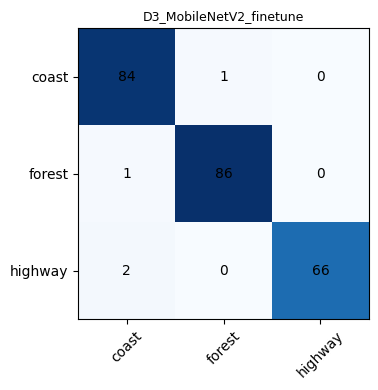

In [21]:
res = pd.DataFrame(results).sort_values("acc", ascending=False)
display(res[["family","tag","acc","f1_macro","f1_weighted"] + [c for c in ("nota",) if c in res]])
res.to_csv("resultados_etapa2.csv", index=False)
print("Referencias de clase -> ML: exactitud 0.81 (F1 macro 0.80) | CNN: exactitud 0.88 (F1 macro 0.87)")
best = res[res.family=="Deep learning"].iloc[0].tag; pb = preds[best]
print("Mejor modelo profundo:", best); print(classification_report(yte, pb, target_names=classes, digits=3))
cm = confusion_matrix(yte, pb)
plt.figure(figsize=(4.5,4)); plt.imshow(cm, cmap="Blues"); plt.xticks(range(K),classes,rotation=45); plt.yticks(range(K),classes); plt.title(best, fontsize=9)
for (i,j),v in np.ndenumerate(cm): plt.text(j,i,v,ha="center",va="center")
plt.tight_layout(); plt.savefig("cm_etapa2.png", dpi=200); plt.show()

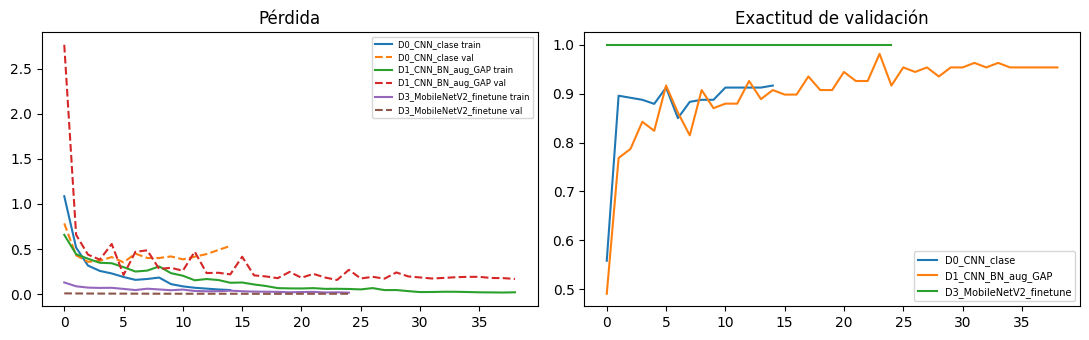

In [22]:
# Curvas de entrenamiento: sobreajuste de la CNN de clase vs CNN con BN/GAP/aumento
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for t in ("D0_CNN_clase", "D1_CNN_BN_aug_GAP", "D3_MobileNetV2_finetune"):
    ax[0].plot(hist[t]["loss"], label=f"{t} train"); ax[0].plot(hist[t]["val_loss"], "--", label=f"{t} val")
    ax[1].plot(hist[t]["val_accuracy"], label=t)
ax[0].set_title("Pérdida"); ax[1].set_title("Exactitud de validación"); ax[0].legend(fontsize=6); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.savefig("curvas_etapa2.png", dpi=200); plt.show()

In [23]:
# ¿La mejora es estadísticamente significativa? McNemar: mejor modelo profundo vs CNN de clase (misma prueba)
from statsmodels.stats.contingency_tables import mcnemar
a, b = preds[best]==yte, preds["D0_CNN_clase"]==yte
tab = [[(a&b).sum(), (a&~b).sum()], [(~a&b).sum(), (~a&~b).sum()]]
print(pd.DataFrame(tab, index=[f"{best} ok","mal"], columns=["D0 ok","D0 mal"])); print("McNemar exacto p =", mcnemar(tab, exact=True).pvalue)

                            D0 ok  D0 mal
D3_MobileNetV2_finetune ok    217      19
mal                             3       1
McNemar exacto p = 0.0008554458618164062


## 4. Interpretabilidad: Grad-CAM
$\alpha_k^c=\tfrac1{Z}\sum_{i,j}\tfrac{\partial y^c}{\partial A^k_{ij}}$ y $L^c_{\text{Grad-CAM}}=\mathrm{ReLU}\big(\sum_k\alpha^c_k A^k\big)$: muestra **dónde mira** la red para decidir la clase; útil para detectar atajos (p. ej. decidir *coast* solo por el azul del cielo).

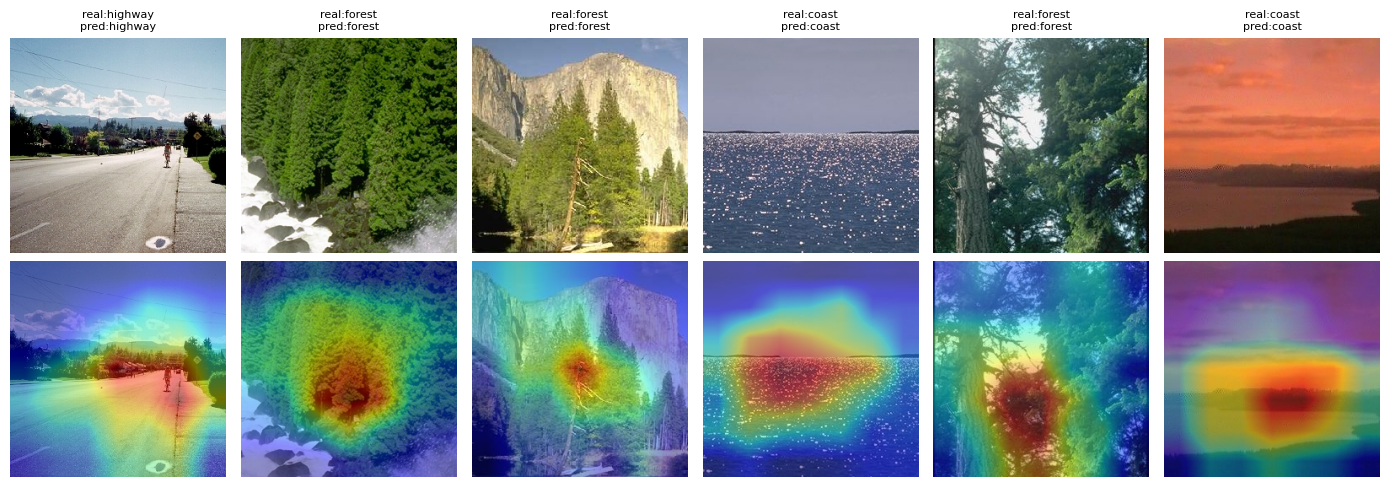

In [24]:
feat = keras.Model(base_tl.input, base_tl.get_layer("out_relu").output)
head = m_tl.layers[-1]
def gradcam(img):
    x = keras.applications.mobilenet_v2.preprocess_input(cv2.resize(img, (TL, TL)).astype("float32")[None])
    with tf.GradientTape() as tape:
        A = feat(x); tape.watch(A)
        s = head(tf.reduce_mean(A, axis=(1,2))); c = tf.argmax(s[0]); score = s[:, c]
    g = tape.gradient(score, A); w = tf.reduce_mean(g, axis=(1,2), keepdims=True)
    cam = tf.nn.relu(tf.reduce_sum(w*A, -1))[0].numpy(); cam /= cam.max()+1e-8
    return cv2.resize(cam, (IMG, IMG)), int(c)

fig, ax = plt.subplots(2, 6, figsize=(14, 5))
for j, i in enumerate(np.random.RandomState(SEED).choice(len(Xte), 6, replace=False)):
    cam, c = gradcam(Xte[i])
    ax[0][j].imshow(Xte[i]); ax[0][j].set_title(f"real:{classes[yte[i]]}\npred:{classes[c]}", fontsize=8); ax[0][j].axis("off")
    ax[1][j].imshow(Xte[i]); ax[1][j].imshow(cam, cmap="jet", alpha=0.45); ax[1][j].axis("off")
plt.tight_layout(); plt.savefig("gradcam_etapa2.png", dpi=200); plt.show()

## 5. Vínculo con la tesis: ¿la textura explica los errores?
Por imagen de prueba: (i) $\mathrm{Var}(\nabla^2 I)$ (nitidez/detalle) y (ii) número de esquinas FAST, proxies del nivel de textura que en VI-SLAM condiciona la detección de *features* y la tasa de fallo de *tracking*.
Se comparan los errores de la línea base de color (que no usa textura) y del mejor modelo profundo.

In [25]:
def texture_idx(im):
    g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(g, cv2.CV_64F).var(), len(cv2.FastFeatureDetector_create(threshold=20).detect(g))
T = np.array([texture_idx(im) for im in Xte])
df = pd.DataFrame(dict(lapvar=T[:,0], fast=T[:,1], clase=[classes[i] for i in yte],
                       err_base=(preds["base_RGB_MLP"]!=yte).astype(int), err_best=(preds[best]!=yte).astype(int)))
df["tercil_textura"] = pd.qcut(df.fast.rank(method="first"), 3, labels=["baja","media","alta"])
tex = df.groupby("tercil_textura")[["err_base","err_best"]].agg(["mean","sum"]); tex["n"] = df.groupby("tercil_textura").size()
display(tex); tex.to_csv("textura_error_etapa2.csv")
display(df.groupby("clase")[["lapvar","fast"]].mean().round(1))
from scipy.stats import pointbiserialr
for e in ("err_base","err_best"): print(e, "corr con FAST:", pointbiserialr(df[e], df.fast))

err_base     err_best       n
                   mean sum     mean sum    
tercil_textura                              
baja             0.2625  21   0.0250   2  80
media            0.2875  23   0.0125   1  80
alta             0.1000   8   0.0125   1  80

,lapvar,fast
clase,,
coast,1260.4,614.4
forest,7368.2,2978.3
highway,919.1,489.6


err_base corr con FAST: SignificanceResult(statistic=np.float64(-0.1777130294254855), pvalue=np.float64(0.005766806108799877))
err_best corr con FAST: SignificanceResult(statistic=np.float64(-0.02406958989022515), pvalue=np.float64(0.710643889222606))


In [26]:
import shutil, glob
from google.colab import files
print(os.getcwd(), os.listdir("."))
shutil.make_archive("/content/resultados_etapa2", "zip", ".")
files.download("/content/resultados_etapa2.zip")

/content/drive/MyDrive/PhD/2026_02/Vision_por_computador/Ejercicio 2/resultados/etapa2 ['resultados_etapa2.csv', 'cm_etapa2.png', 'curvas_etapa2.png', 'gradcam_etapa2.png', 'textura_error_etapa2.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Guía para redactar el análisis
1. **Por qué los momentos de color llegan a ~81 %:** *forest* es verde y texturizado, *coast* azul; *highway* comparte paleta (cielo + gris) con *coast* y es la clase con menor F1 en la línea base (0.72). Ver matriz de confusión.
2. **CNN de clase (D0):** 94 % de sus parámetros están en la capa densa; comentar la curva de validación (mejor época ≈ 7–8 y luego sobreajuste) y el sesgo optimista de validar con la prueba.
3. **D1 vs D0:** efecto de GAP, BatchNorm, profundidad (campo receptivo) y aumento de datos, con parámetros y curvas.
4. **Transferencia (D2, D3):** con ~600 imágenes de entrenamiento, los filtros de ImageNet superan a una CNN desde cero; comparar parámetros entrenables y LR.
5. **Ensamble (D4):** ¿mejora sobre max(D1, D3)? Relacionarlo con la correlación de errores.
6. **McNemar:** con 240 imágenes de prueba, 1 imagen ≈ 0.4 %; decir si la mejora sobre D0 es significativa.
7. **Textura (sección 5):** ¿el error se concentra en baja textura y cambia entre la línea base de color y la CNN? Un resultado positivo o negativo es igualmente informativo para acotar el factor "textura" de la tesis.
8. **Amenazas a la validez:** una sola partición; recomendable repetir con 5 semillas y reportar media ± desviación (IC 95 %).